# CS 412 Machine Learning
## Spring 2026
## Homework 4

---

**Due:** April 27, 11:55 pm  
**Late Accepted Until:** April 29, 11:55 pm

### Student Information

In [ ]:
NAME       = "Abdallah Al Homsi"     # e.g. "Emine Ayşe Sunar"
STUDENT_ID = "34565"        # e.g. "12345"

print(f"Student : {NAME}")
print(f"ID      : {STUDENT_ID}")

Student : Abdallah Al Homsi
ID      : 34565


## Instructions

- **Run all cells before submitting.** All outputs must be visible. The notebook will not be re-run during grading. Cells with no output will receive zero points.
- **Submission:** Upload your notebook as `CS412-HW4-FirstnameLastname.ipynb`.
- **Late policy:** Up to 2 days late accepted with a 10-point penalty per day. Submissions within the first hour after the deadline incur only a 5-point penalty.

---

## Overview

In this assignment, you will build and compare a **Multilayer Perceptron (MLP)** and a **Convolutional Neural Network (CNN)** for image classification on a 10-class subset of **Food-101**, a benchmark dataset of 101,000 food images across 101 categories (pizza, sushi, waffles, etc.), originally published at ECCV 2014. We work with 10 classes to keep training times manageable on Colab. The dataset is available on Sucourse as `Food10.zip`.

**Minimum test accuracy required:**
- MLP: **30%**
- CNN: **50%**

> ⚠️ **Important:** Reaching the minimum accuracy threshold is required. If your model does not meet the threshold, you will receive at most half of the points for that part, even if the rest of your implementation is correct.

---

## Grading

- **Part 1**: Numerical Questions: 20 pts
- **Part 2**: MLP Classifier: 25 pts
- **Part 3**: CNN Classifier: 40 pts
- **Part 4**: Comparison & Analysis: 15 pts
- **Total: 100 pts**

## Part 0: Setup and Data Loading

> 📌 **Note:** This section contains setup and data loading code. Run all cells in this section without modifying them.

Run the cell below to install and import all required libraries. Make sure you are using a GPU runtime on Colab (Runtime > Change runtime type > T4 GPU).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 0.1 Data Loading

Download `Food10.zip` from Sucourse and upload it to your Google Drive **without renaming it**. Then run the cells below to mount your Drive and extract the dataset.

The dataset is a 10-class subset of [Food-101](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/) (Bossard et al., ECCV 2014). It contains 750 training and 250 test images per class across 10 food categories: pizza, sushi, waffles, ice cream, chocolate cake, hamburger, hot dog, ramen, donuts, and fried rice.

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import os

zip_path  = "/content/drive/My Drive/Food10.zip"
target_dir = "/content/data"

if not os.path.exists(os.path.join(target_dir, "train")):
    print("Extracting dataset...")
    !unzip -q "{zip_path}" -d "/content/data"
    print("Extraction complete.")
else:
    print("Dataset already extracted, skipping.")

data_dir = target_dir
print("Using dataset at:", data_dir)

Extracting dataset...
Extraction complete.
Using dataset at: /content/data


### 0.2 Preprocessing and Visualization

We resize all images to 64×64, apply normalization, and split the training data into train (80%) and validation (20%) sets.

In [ ]:
IMG_SIZE = 64
SELECTED_CLASSES = [
    "pizza", "sushi", "waffles", "ice_cream", "chocolate_cake",
    "hamburger", "hot_dog", "ramen", "donuts", "fried_rice"
]

class FoodDataset(Dataset):
    def __init__(self, root_dir, split, transform=None):
        self.transform = transform
        self.samples = []
        split_dir = os.path.join(root_dir, split)
        for label, class_name in enumerate(SELECTED_CLASSES):
            class_dir = os.path.join(split_dir, class_name)
            for fname in os.listdir(class_dir):
                if fname.endswith(".jpg"):
                    self.samples.append((os.path.join(class_dir, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Compute mean and std from training set only
def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
    mean = torch.zeros(3)
    std = torch.zeros(3)
    for images, _ in loader:
        for c in range(3):
            mean[c] += images[:, c, :, :].mean()
            std[c] += images[:, c, :, :].std()
    mean /= len(loader)
    std /= len(loader)
    return mean, std

pre_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])
temp_dataset = FoodDataset(data_dir, "train", transform=pre_transform)
mean, std = compute_mean_std(temp_dataset)
print(f"Mean: {mean}")
print(f"Std:  {std}")

# Define transforms using computed stats
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Create datasets and loaders
full_train_dataset = FoodDataset(data_dir, "train", transform=transform_train)
test_dataset       = FoodDataset(data_dir, "test",  transform=transform_eval)

val_size   = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Mean: tensor([0.5365, 0.4360, 0.3447])
Std:  tensor([0.2607, 0.2582, 0.2591])
Train: 6000 | Val: 1500 | Test: 2500


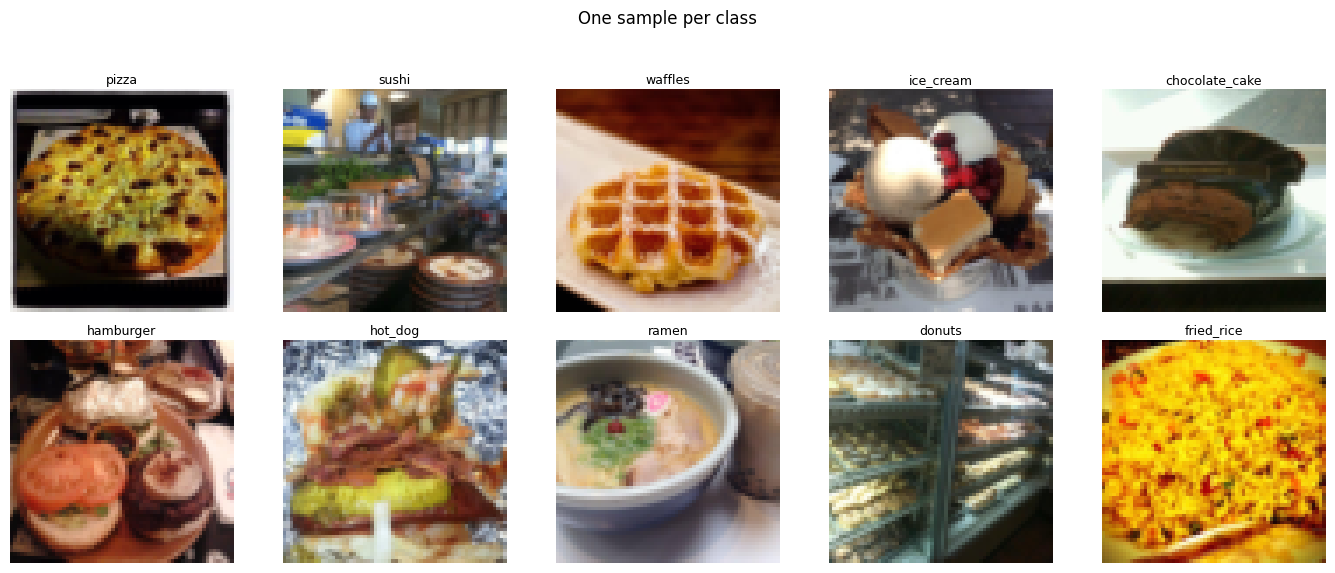

In [ ]:
# Visualize one sample per class
display_dataset = FoodDataset(data_dir, "train", transform=transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
]))

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
shown = {}
idx = 0
while len(shown) < 10:
    img, label = display_dataset[idx]
    if label not in shown:
        shown[label] = img
    idx += 1

for ax, (label, img) in zip(axes.flatten(), sorted(shown.items())):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(SELECTED_CLASSES[label], fontsize=9, pad=4)
    ax.axis("off")

plt.suptitle("One sample per class", fontsize=12)
plt.tight_layout(pad=2.5)
plt.show()

## Part 1: Numerical Questions [20 pts]

> 📌 **Note:** The numerical questions in this section are independent of the Food-101 dataset. The input dimensions and configurations given here are hypothetical and are not related to the Food-101 dataset.

Answer the following questions in the answer cells provided. No code is needed for this part.

### Question 1.1 — Output Size [8 pts]

You have an input feature map of spatial size **40×40** with **3 channels**. You apply a convolutional layer with the following configuration:
- Filter size: 5×5
- Number of filters: 16
- Stride: 2
- Padding: 1

**(a)** What is the spatial size (height × width) of the output feature map? Show your calculation using the formula $W_{out} = \lfloor \frac{W + 2P - F}{S} \rfloor + 1$.

**(b)** What is the total number of learnable parameters in this layer, including biases?

**(c)** What would the output spatial size be if you instead used stride 1 and padding 2? Show your work. What is this special case of padding called, and what is its purpose?

**Your answer for 1.1:**

(a) 19x19 since floor of (40+2-5/2) + 1

(b) 1216 since 5x5x3 = 75 and 75+1 = 76 and 16 times 76 gives 1216

(c) 40x40 since 40+2x2-5/1 floor of course and then add 1 gives 40 so 40x40

### Question 1.2 — Conceptual Questions [12 pts]

**(a)** What is **weight sharing** in a convolutional layer and why does it make CNNs more parameter-efficient than MLPs for image inputs?

**(b)** A CNN is said to be **translation equivariant**. What does this mean? Give a concrete example using the food images in this dataset.

**(c)** A max pooling layer with a 2×2 window and stride 2 is applied to a feature map of size 32×32×64. What is the output size? How many learnable parameters does this pooling layer have, and why?

**Your answer for 1.2:**

(a) Weight Sharing means the same filters are being applied all over the spatial areas or locations of the image, instead of having to learn seperate weights for every single pixel in the input the CNN reuses one small set of weights over the image. This is the reason of why CNNs are are much more efficient than MLP because it connects every single pixel to every neuron there is with different weights making it have way more parameters

(b) CNNs being translation equivariant means that if input image shifts the feature map output shifts in the same way so the pattern stays recognizable even when the position changes. For instance, if a pizza appears in the center of the image and the CNN detects pizza related edges or textures, then moving the pizza slightly to the left will also move the activation in the feature map to the left, rather than making the feature disapper completely

(c) 16x16x64 because 32-2/2 +1 gives 16 so 16x16 and then multiply with 64

## Part 2: MLP Classifier [25 pts]

In this part, you will implement and train a Multilayer Perceptron (MLP) to classify food images. For the MLP, images must be **flattened** into a 1D vector before being fed into the network.

**Requirement:** Your MLP must achieve at least **30% top-1 accuracy** on the test set.

### 2.1 Model Implementation [10 pts]

Implement your MLP by completing the class below. You are free to choose the number of layers and neurons, but your network must satisfy the following:
- At least 2 hidden layers
- ReLU activations
- At least one Dropout layer

The input dimension is 64×64×3 = 12,288.

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim=64*64*3, num_classes=10):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
        )


    def forward(self, x):
         x = x.view(x.size(0), -1)   # flatten images
         return self.net(x)

mlp_model = MLP().to(device)
print(mlp_model)
total_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=12288, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=10, bias=True)
  )
)
Total trainable parameters: 13,242,634


### 2.2 Training [10 pts]

Train your MLP using the training set and evaluate on the validation set each epoch. You must:
- Use `CrossEntropyLoss`
- Train for at least 15 epochs
- Print training loss and validation accuracy per epoch
- Plot training loss and validation accuracy curves

In [ ]:
def train_model(model, train_loader, val_loader, num_epochs=20, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_accuracies = [], []

    train_losses, val_accuracies = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        val_accuracies.append(val_acc)
        print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}  Val Acc: {val_acc:.2f}%")

    return train_losses, val_accuracies

mlp_train_losses, mlp_val_accs = train_model(mlp_model, train_loader, val_loader, num_epochs=20)

Epoch [1/20]  Loss: 2.2431  Val Acc: 27.27%
Epoch [2/20]  Loss: 2.1137  Val Acc: 25.33%
Epoch [3/20]  Loss: 2.0620  Val Acc: 27.13%
Epoch [4/20]  Loss: 2.0094  Val Acc: 28.87%
Epoch [5/20]  Loss: 1.9737  Val Acc: 29.00%
Epoch [6/20]  Loss: 1.9475  Val Acc: 31.27%
Epoch [7/20]  Loss: 1.9270  Val Acc: 32.07%
Epoch [8/20]  Loss: 1.8933  Val Acc: 31.67%
Epoch [9/20]  Loss: 1.8508  Val Acc: 32.73%
Epoch [10/20]  Loss: 1.8225  Val Acc: 30.93%
Epoch [11/20]  Loss: 1.7880  Val Acc: 30.20%
Epoch [12/20]  Loss: 1.7837  Val Acc: 29.47%
Epoch [13/20]  Loss: 1.7542  Val Acc: 30.47%
Epoch [14/20]  Loss: 1.7227  Val Acc: 31.27%
Epoch [15/20]  Loss: 1.6691  Val Acc: 30.80%
Epoch [16/20]  Loss: 1.6527  Val Acc: 34.53%
Epoch [17/20]  Loss: 1.6051  Val Acc: 30.80%
Epoch [18/20]  Loss: 1.5933  Val Acc: 32.20%
Epoch [19/20]  Loss: 1.5637  Val Acc: 31.80%
Epoch [20/20]  Loss: 1.5195  Val Acc: 30.93%


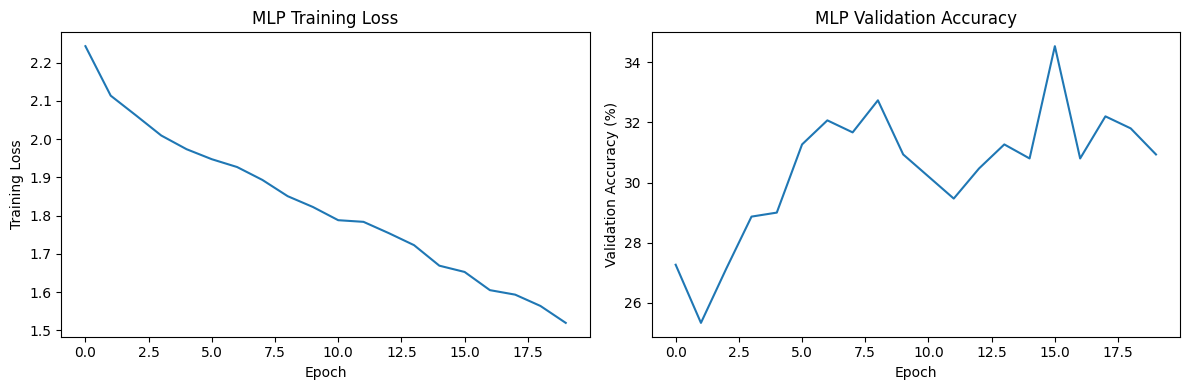

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(mlp_train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Training Loss")

plt.subplot(1, 2, 2)
plt.plot(mlp_val_accs)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("MLP Validation Accuracy")

plt.tight_layout()
plt.show()

### 2.3 Test Evaluation [5 pts]

Evaluate your trained MLP on the test set. You must meet the 30% threshold to receive full marks.

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100 * correct / total
    return acc, all_preds, all_labels

mlp_test_acc, mlp_preds, mlp_labels = evaluate(mlp_model, test_loader)
print(f"MLP Test Accuracy: {mlp_test_acc:.2f}%")
assert mlp_test_acc >= 30.0, f"Accuracy {mlp_test_acc:.2f}% is below the required 30% threshold!"
print("Threshold requirement met.")

MLP Test Accuracy: 30.72%
Threshold requirement met.


## Part 3: CNN Classifier [40 pts]

Now you will implement a CNN. Unlike the MLP, the CNN operates directly on the 2D spatial structure of the image, so do not flatten the input at the beginning.

**Requirement:** Your CNN must achieve at least **50% top-1 accuracy** on the test set.

### 3.1 Model Implementation [15 pts]

Implement your CNN by completing the class below. Your network must satisfy the following:
- At least 3 convolutional layers
- ReLU activations after each conv layer
- At least one max pooling layer
- At least one Dropout layer in the classifier head
- The final layer must output logits for 10 classes

> 💡 **Tip:** If you are struggling to meet the accuracy threshold, consider adding `nn.BatchNorm2d` after your convolutional layers. Batch normalization stabilizes training and often leads to faster convergence and better performance.

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        # TODO: Define your convolutional layers here
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 64 -> 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 16 -> 8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)    # 8 -> 4
        )
        # TODO: Define your classifier head here
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        # TODO: Flatten the output of the convolutional layers before passing to the classifier
        return self.classifier(x)

cnn_model = CNN().to(device)
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (

### 3.2 Training [15 pts]

Train your CNN using the same `train_model` function from Part 2. Plot the training curves.

In [ ]:
cnn_train_losses, cnn_val_accs = train_model(cnn_model, train_loader, val_loader, num_epochs=20)

Epoch [1/20]  Loss: 2.2194  Val Acc: 22.13%
Epoch [2/20]  Loss: 2.0263  Val Acc: 32.07%
Epoch [3/20]  Loss: 1.9505  Val Acc: 37.47%
Epoch [4/20]  Loss: 1.8841  Val Acc: 37.33%
Epoch [5/20]  Loss: 1.8112  Val Acc: 39.20%
Epoch [6/20]  Loss: 1.7358  Val Acc: 34.87%
Epoch [7/20]  Loss: 1.7115  Val Acc: 40.20%
Epoch [8/20]  Loss: 1.6495  Val Acc: 43.40%
Epoch [9/20]  Loss: 1.5917  Val Acc: 45.87%
Epoch [10/20]  Loss: 1.5483  Val Acc: 47.53%
Epoch [11/20]  Loss: 1.5363  Val Acc: 48.87%
Epoch [12/20]  Loss: 1.4830  Val Acc: 47.73%
Epoch [13/20]  Loss: 1.4572  Val Acc: 49.47%
Epoch [14/20]  Loss: 1.3941  Val Acc: 46.07%
Epoch [15/20]  Loss: 1.3743  Val Acc: 51.27%
Epoch [16/20]  Loss: 1.3355  Val Acc: 50.27%
Epoch [17/20]  Loss: 1.2755  Val Acc: 50.60%
Epoch [18/20]  Loss: 1.2488  Val Acc: 51.73%
Epoch [19/20]  Loss: 1.2395  Val Acc: 51.00%
Epoch [20/20]  Loss: 1.1735  Val Acc: 52.47%


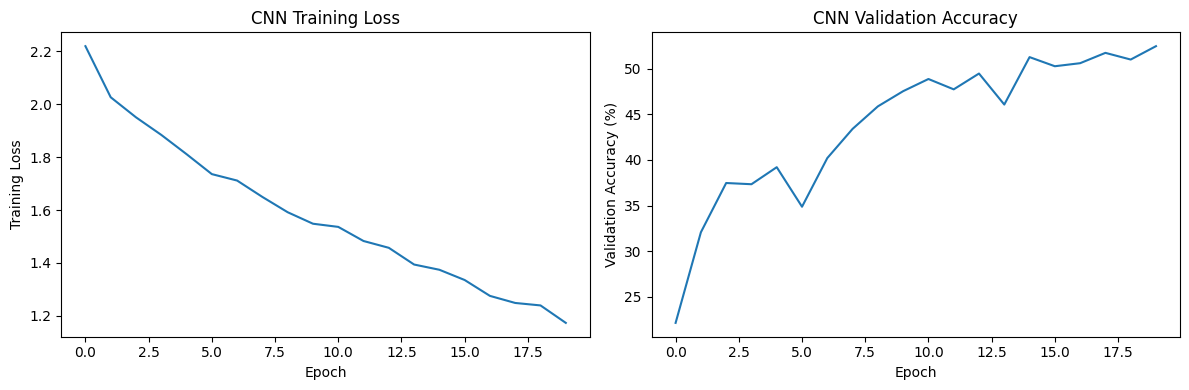

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(cnn_train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")

plt.subplot(1, 2, 2)
plt.plot(cnn_val_accs)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("CNN Validation Accuracy")

plt.tight_layout()
plt.show()

### 3.3 Test Evaluation [10 pts]

Evaluate your trained CNN on the test set. You must meet the 50% threshold to receive full marks.

In [ ]:
cnn_test_acc, cnn_preds, cnn_labels = evaluate(cnn_model, test_loader)

In [ ]:
print(f"CNN Test Accuracy: {cnn_test_acc:.2f}%")
assert cnn_test_acc >= 50.0, f"Accuracy {cnn_test_acc:.2f}% is below the required 50% threshold!"
print("Threshold requirement met.")

CNN Test Accuracy: 57.20%
Threshold requirement met.


## Part 4: Comparison and Analysis [15 pts]

### 4.1 Side-by-Side Validation Accuracy Comparison [5 pts]

Plot both models' validation accuracy on the same graph.

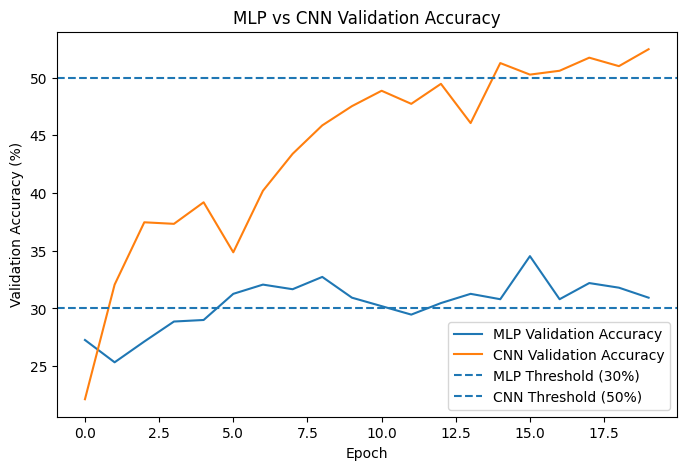

Final MLP Test Accuracy: 30.72%
Final CNN Test Accuracy: 57.20%


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(mlp_val_accs, label="MLP Validation Accuracy")
plt.plot(cnn_val_accs, label="CNN Validation Accuracy")

plt.axhline(y=30, linestyle="--", label="MLP Threshold (30%)")
plt.axhline(y=50, linestyle="--", label="CNN Threshold (50%)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("MLP vs CNN Validation Accuracy")
plt.legend()
plt.show()

print(f"Final MLP Test Accuracy: {mlp_test_acc:.2f}%")
print(f"Final CNN Test Accuracy: {cnn_test_acc:.2f}%")

### 4.2 Discussion [10 pts]

**(a)** If correctly implemented, the CNN should significantly outperform the MLP on this task. Explain why this is expected using the concepts of **locality** and **weight sharing**. Why are these properties particularly useful for food image classification?

**(b)** Look at your training curves for both models. Which model shows signs of overfitting, underfitting, or neither? Suggest one concrete change you could make to improve the weaker model and explain why it would help.

**Your answer for 4.2:**

(a) The CNN outperformed the MLP because CNNs are designed for image data. They use locality, which means they learn from small local regions of the image such as edges, textures, and shapes. This is useful for food image classification because food categories are often recognized by local visual patterns like the texture of waffles, the shape of donuts, or the ingredients visible on pizza. CNNs also use weight sharing, meaning the same filter is applied across the image. This reduces the number of parameters and helps the model detect the same feature even if it appears in different positions. In contrast, the MLP flattens the image and loses spatial structure, so it cannot use these visual relationships as effectively.

(b) The MLP appears to be underfitting. Although the training loss decreases steadily, the validation accuracy remains fairly low and only reaches around the threshold. This suggests the model is not capturing the image patterns strongly enough. One concrete improvement would be to add more capacity or improve regularization tuning in the MLP, for example by reducing dropout slightly or training longer. However, the main limitation is that the MLP flattens the images and ignores spatial structure, so it is still less suitable than a CNN for image classification.